# WilpattuVision — Model Update v2

This notebook extends the original 13-species WilpattuVision classifier with:

- **2 new species**: Fishing cat, Sri Lankan jungle fowl
- **1 new "None of the above" class**, so the model has an explicit way to say *"this isn't one of my species"* instead of being forced to pick its closest guess among the known species every time
- **A second model**: MobileNetV3Small, trained on the same dataset and converted to TensorFlow.js format so the PWA can download it once and run predictions fully offline in the browser (EfficientNetB3 stays server-side since it's too large for a comfortable browser download/cache)


In [1]:
!pip install -q requests pillow scikit-learn seaborn tensorflow tensorflowjs

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/89.1 kB ? eta -:--:--
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.1/89.1 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/53.0 kB ? eta -:--:--
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.1/16.1 MB 67.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 645.0/645.0 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 137.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 86.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 8.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ydf-tf 2.20.0 requires tensorflow==2.20.0, but you have tensorflow 2.19.0 which is incompatible.
db-dtypes 1.7.1 requires packaging>=24.2

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os
PROJECT_DIR = '/content/drive/MyDrive/WilpattuVision'
os.makedirs(PROJECT_DIR, exist_ok=True)

Mounted at /content/drive


In [ ]:

import os
import time
import requests


PROJECT_DIR = '/content/drive/MyDrive/WilpattuVision'
RAW_DATA_DIR = os.path.join(PROJECT_DIR, 'data_raw')

SPECIES = [
    {"display_name": "Sri Lankan leopard",      "search_query": "Panthera pardus kotiya"},
    {"display_name": "Asian elephant",          "search_query": "Asian elephant"},
    {"display_name": "Sloth bear",               "search_query": "Sloth bear"},
    {"display_name": "Spotted deer",             "search_query": "Spotted deer"},
    {"display_name": "Sambar deer",              "search_query": "Sambar deer"},
    {"display_name": "Mugger crocodile",         "search_query": "Mugger crocodile"},
    {"display_name": "Sri Lankan peacock",       "search_query": "Indian peafowl"},
    {"display_name": "Sri Lankan grey langur",   "search_query": "Semnopithecus priam thersites"},
    {"display_name": "Water buffalo",            "search_query": "Water buffalo"},
    {"display_name": "Golden jackal",            "search_query": ["Golden jackal", "Indian rock python"]},
    {"display_name": "Crested serpent eagle",    "search_query": "Crested serpent eagle"},
    {"display_name": "Wild boar",                "search_query": "Wild boar"},
    {"display_name": "Bengal monitor lizard",    "search_query": "Bengal monitor lizard"},

    {"display_name": "Fishing cat",              "search_query": "Fishing cat"},
    {"display_name": "Sri Lankan jungle fowl",   "search_query": ["Sri Lankan Junglefowl",
                                                                    "Ceylon Junglefowl",
                                                                    "Gallus lafayettii"]},
]









IMAGES_PER_SPECIES = 300
PHOTO_SIZE = "medium"
MIN_SRI_LANKA_IMAGES_BEFORE_FALLBACK = 100
MIN_TOTAL_IMAGES_BEFORE_TRYING_NEXT_CANDIDATE = 200

INATURALIST_API = "https://api.inaturalist.org/v1"


def get_sri_lanka_place_id():
    resp = requests.get(f"{INATURALIST_API}/places/autocomplete", params={"q": "Sri Lanka"})
    resp.raise_for_status()
    results = resp.json()["results"]
    for place in results:
        if place["display_name"].strip().lower() == "sri lanka":
            return place["id"]
    return results[0]["id"]


def get_taxon_id(search_query):
    resp = requests.get(f"{INATURALIST_API}/taxa", params={"q": search_query, "per_page": 5})
    resp.raise_for_status()
    results = resp.json()["results"]
    if not results:
        print(f"  WARNING: no taxon found for '{search_query}'")
        return None
    preferred_ranks = {"species", "subspecies"}
    for r in results:
        if r.get("rank") in preferred_ranks:
            return r["id"], r.get("name"), r.get("rank")
    return results[0]["id"], results[0].get("name"), results[0].get("rank")


def download_species_images(species_name, taxon_id, place_id, target_count,
                              out_dir, start_index=0, source_tag="SL"):
    os.makedirs(out_dir, exist_ok=True)
    downloaded = 0
    page = 1
    per_page = 50

    while downloaded < target_count:
        params = {
            "taxon_id": taxon_id,
            "photos": "true",
            "quality_grade": "research",
            "per_page": per_page,
            "page": page,
        }
        if place_id is not None:
            params["place_id"] = place_id

        resp = requests.get(f"{INATURALIST_API}/observations", params=params)
        resp.raise_for_status()
        results = resp.json().get("results", [])
        if not results:
            print(f"    No more observations available from this source "
                  f"(got {downloaded}/{target_count} in this call)")
            break

        for obs in results:
            if downloaded >= target_count:
                break
            for photo in obs.get("photos", []):
                if downloaded >= target_count:
                    break
                url = photo["url"].replace("square", PHOTO_SIZE)
                try:
                    img_resp = requests.get(url, timeout=15)
                    if img_resp.status_code == 200:
                        file_index = start_index + downloaded
                        filename = os.path.join(
                            out_dir,
                            f"{species_name.replace(' ', '_')}_{source_tag}_{file_index:04d}.jpg",
                        )
                        with open(filename, "wb") as f:
                            f.write(img_resp.content)
                        downloaded += 1
                except requests.RequestException:
                    continue

        page += 1
        time.sleep(1)

    return downloaded


def try_one_candidate(search_query, display_name, place_id, species_folder, target_count):
    taxon_result = get_taxon_id(search_query)
    if taxon_result is None:
        print(f"    WARNING: no taxon found for candidate '{search_query}'")
        return 0, 0, None

    taxon_id, matched_name, matched_rank = taxon_result
    print(f"    Matched iNaturalist taxon: '{matched_name}' "
          f"(id={taxon_id}, rank={matched_rank})")

    print(f"    Searching Sri Lanka-tagged observations...")
    sl_count = download_species_images(
        species_name=display_name, taxon_id=taxon_id, place_id=place_id,
        target_count=target_count, out_dir=species_folder,
        start_index=0, source_tag="SL",
    )
    print(f"      -> {sl_count} Sri Lanka-tagged images")

    global_count = 0
    if sl_count < MIN_SRI_LANKA_IMAGES_BEFORE_FALLBACK:
        remaining = target_count - sl_count
        print(f"      Below {MIN_SRI_LANKA_IMAGES_BEFORE_FALLBACK} -- "
              f"topping up with {remaining} global images...")
        global_count = download_species_images(
            species_name=display_name, taxon_id=taxon_id, place_id=None,
            target_count=remaining, out_dir=species_folder,
            start_index=sl_count, source_tag="GLOBAL",
        )
        print(f"      -> {global_count} global images added")

    return sl_count, global_count, (matched_name, matched_rank)


def main():
    print("Looking up Sri Lanka place_id...")
    place_id = get_sri_lanka_place_id()
    print(f"Sri Lanka place_id = {place_id}\n")

    summary = {}

    for entry in SPECIES:
        display_name = entry["display_name"]
        search_queries = entry["search_query"]
        if isinstance(search_queries, str):
            search_queries = [search_queries]

        print(f"Processing: {display_name}")
        species_folder = os.path.join(RAW_DATA_DIR, display_name.replace(" ", "_"))

        existing_count = 0
        if os.path.isdir(species_folder):
            existing_count = len([
                f for f in os.listdir(species_folder)
                if os.path.isfile(os.path.join(species_folder, f))
            ])









        if existing_count > 0:
            print(f"  SKIPPED -- '{species_folder}' already has "
                  f"{existing_count} image(s) from a previous run -- "
                  f"left untouched.\n")
            summary[display_name] = {"sri_lanka": existing_count, "global": 0,
                                      "used_query": "(already downloaded)"}
            continue

        best_result = None
        for i, query in enumerate(search_queries):
            label = "primary" if i == 0 else f"fallback #{i}"
            print(f"  Trying {label} name: '{query}'")

            sl_count, global_count, taxon_info = try_one_candidate(
                search_query=query, display_name=display_name, place_id=place_id,
                species_folder=species_folder, target_count=IMAGES_PER_SPECIES,
            )
            total = sl_count + global_count

            if best_result is None or total > (best_result["sri_lanka"] + best_result["global"]):
                best_result = {"sri_lanka": sl_count, "global": global_count,
                                "used_query": query, "taxon_info": taxon_info}

            if total >= MIN_TOTAL_IMAGES_BEFORE_TRYING_NEXT_CANDIDATE:
                print(f"  '{query}' produced {total} images -- good enough, "
                      f"not trying further candidates\n")
                break
            elif i < len(search_queries) - 1:
                print(f"  '{query}' only produced {total} images "
                      f"(below {MIN_TOTAL_IMAGES_BEFORE_TRYING_NEXT_CANDIDATE}) "
                      f"-- trying next candidate name...\n")
            else:
                print(f"  '{query}' only produced {total} images. "
                      f"No more candidate names to try.\n")

        summary[display_name] = best_result

    print("=" * 80)
    print("DOWNLOAD SUMMARY")
    print("=" * 80)
    print(f"{'Species':28s} {'Sri Lanka':>10s} {'Global':>8s} {'Total':>8s}  Used name")
    for display_name, result in summary.items():
        total = result["sri_lanka"] + result["global"]
        flag = "  <-- LOW" if total < 80 else ""
        print(f"{display_name:28s} {result['sri_lanka']:>10d} {result['global']:>8d} "
              f"{total:>8d}{flag}  ({result['used_query']})")


if __name__ == "__main__":
    main()


Looking up Sri Lanka place_id...
Sri Lanka place_id = 7077

Processing: Sri Lankan leopard
  SKIPPED -- '/content/drive/MyDrive/WilpattuVision/data_raw/Sri_Lankan_leopard' already has 300 image(s) from a previous run -- left untouched.

Processing: Asian elephant
  SKIPPED -- '/content/drive/MyDrive/WilpattuVision/data_raw/Asian_elephant' already has 300 image(s) from a previous run -- left untouched.

Processing: Sloth bear
  SKIPPED -- '/content/drive/MyDrive/WilpattuVision/data_raw/Sloth_bear' already has 300 image(s) from a previous run -- left untouched.

Processing: Spotted deer
  SKIPPED -- '/content/drive/MyDrive/WilpattuVision/data_raw/Spotted_deer' already has 300 image(s) from a previous run -- left untouched.

Processing: Sambar deer
  SKIPPED -- '/content/drive/MyDrive/WilpattuVision/data_raw/Sambar_deer' already has 300 image(s) from a previous run -- left untouched.

Processing: Mugger crocodile
  SKIPPED -- '/content/drive/MyDrive/WilpattuVision/data_raw/Mugger_crocodil

In [ ]:


import os
import time
import requests

PROJECT_DIR = '/content/drive/MyDrive/WilpattuVision'
RAW_DATA_DIR = os.path.join(PROJECT_DIR, 'data_raw')
NONE_CLASS_FOLDER = os.path.join(RAW_DATA_DIR, 'None_of_the_above')





DISTRACTOR_SPECIES = [
    "Rusty-spotted cat",
    "Toque macaque",
    "Ruddy mongoose",
    "Black-naped hare",
    "Indian flying fox",
    "Asian water monitor",
    "Painted stork",
    "Asian openbill",
    "White-bellied sea eagle",
    "Domestic dog",
    "Brown fish owl",
    "Indian pangolin",
]

IMAGES_PER_DISTRACTOR = 25

PHOTO_SIZE = "medium"
MIN_SRI_LANKA_IMAGES_BEFORE_FALLBACK = 10

INATURALIST_API = "https://api.inaturalist.org/v1"


def get_sri_lanka_place_id():
    resp = requests.get(f"{INATURALIST_API}/places/autocomplete", params={"q": "Sri Lanka"})
    resp.raise_for_status()
    results = resp.json()["results"]
    for place in results:
        if place["display_name"].strip().lower() == "sri lanka":
            return place["id"]
    return results[0]["id"]


def get_taxon_id(search_query):
    resp = requests.get(f"{INATURALIST_API}/taxa", params={"q": search_query, "per_page": 5})
    resp.raise_for_status()
    results = resp.json()["results"]
    if not results:
        print(f"  WARNING: no taxon found for '{search_query}'")
        return None
    preferred_ranks = {"species", "subspecies"}
    for r in results:
        if r.get("rank") in preferred_ranks:
            return r["id"], r.get("name"), r.get("rank")
    return results[0]["id"], results[0].get("name"), results[0].get("rank")


def download_species_images(species_name, taxon_id, place_id, target_count,
                              out_dir, start_index=0, source_tag="SL"):
    os.makedirs(out_dir, exist_ok=True)
    downloaded = 0
    page = 1
    per_page = 50

    while downloaded < target_count:
        params = {
            "taxon_id": taxon_id,
            "photos": "true",
            "quality_grade": "research",
            "per_page": per_page,
            "page": page,
        }
        if place_id is not None:
            params["place_id"] = place_id

        resp = requests.get(f"{INATURALIST_API}/observations", params=params)
        resp.raise_for_status()
        results = resp.json().get("results", [])
        if not results:
            break

        for obs in results:
            if downloaded >= target_count:
                break
            for photo in obs.get("photos", []):
                if downloaded >= target_count:
                    break
                url = photo["url"].replace("square", PHOTO_SIZE)
                try:
                    img_resp = requests.get(url, timeout=15)
                    if img_resp.status_code == 200:
                        file_index = start_index + downloaded
                        safe_name = species_name.replace(" ", "_").replace("/", "_")
                        filename = os.path.join(
                            out_dir, f"{safe_name}_{source_tag}_{file_index:04d}.jpg"
                        )
                        with open(filename, "wb") as f:
                            f.write(img_resp.content)
                        downloaded += 1
                except requests.RequestException:
                    continue

        page += 1
        time.sleep(1)

    return downloaded


def main():
    print("Looking up Sri Lanka place_id...")
    place_id = get_sri_lanka_place_id()
    print(f"Sri Lanka place_id = {place_id}\n")

    os.makedirs(NONE_CLASS_FOLDER, exist_ok=True)



    running_index = len([
        f for f in os.listdir(NONE_CLASS_FOLDER)
        if os.path.isfile(os.path.join(NONE_CLASS_FOLDER, f))
    ])
    print(f"Starting with {running_index} existing image(s) already in "
          f"'{NONE_CLASS_FOLDER}' (e.g. any manually-added scenery photos "
          f"-- these are left untouched).\n")

    summary = {}
    for species in DISTRACTOR_SPECIES:
        print(f"Processing distractor: {species}")





        safe_name = species.replace(" ", "_").replace("/", "_")
        already_have = len([
            f for f in os.listdir(NONE_CLASS_FOLDER)
            if os.path.isfile(os.path.join(NONE_CLASS_FOLDER, f))
            and f.startswith(safe_name + "_")
        ])
        if already_have >= IMAGES_PER_DISTRACTOR:
            print(f"  SKIPPED -- already have {already_have} image(s) for "
                  f"this distractor -- left untouched.\n")
            summary[species] = already_have
            continue

        taxon_result = get_taxon_id(species)
        if taxon_result is None:
            summary[species] = 0
            continue
        taxon_id, matched_name, matched_rank = taxon_result
        print(f"  Matched: '{matched_name}' (id={taxon_id}, rank={matched_rank})")

        sl_count = download_species_images(
            species_name=species, taxon_id=taxon_id, place_id=place_id,
            target_count=IMAGES_PER_DISTRACTOR, out_dir=NONE_CLASS_FOLDER,
            start_index=running_index, source_tag="SL",
        )
        running_index += sl_count

        if sl_count < MIN_SRI_LANKA_IMAGES_BEFORE_FALLBACK:
            remaining = IMAGES_PER_DISTRACTOR - sl_count
            global_count = download_species_images(
                species_name=species, taxon_id=taxon_id, place_id=None,
                target_count=remaining, out_dir=NONE_CLASS_FOLDER,
                start_index=running_index, source_tag="GLOBAL",
            )
            running_index += global_count
            sl_count += global_count

        summary[species] = sl_count
        print(f"  -> {sl_count} images added\n")

    total = sum(summary.values())
    print("=" * 60)
    print(f"'None of the above' download summary -- {total} images added "
          f"this run, {running_index} total now in the folder")
    print("=" * 60)
    for species, count in summary.items():
        print(f"  {species:25s} {count:>4d}")


if __name__ == "__main__":
    main()


In [ ]:


import os
import shutil
import hashlib
import random
from PIL import Image

PROJECT_DIR = '/content/drive/MyDrive/WilpattuVision'
RAW_DATA_DIR = os.path.join(PROJECT_DIR, 'data_raw')
CLEAN_DATA_DIR = os.path.join(PROJECT_DIR, 'data')

TRAIN_SPLIT = 0.70
VAL_SPLIT = 0.15
TEST_SPLIT = 0.15

SKIP_ALREADY_SPLIT = True

EXPECTED_SPECIES = [
    "Sri Lankan leopard",
    "Asian elephant",
    "Sloth bear",
    "Spotted deer",
    "Sambar deer",
    "Mugger crocodile",
    "Sri Lankan peacock",
    "Sri Lankan grey langur",
    "Water buffalo",
    "Golden jackal",
    "Crested serpent eagle",
    "Wild boar",
    "Bengal monitor lizard",
    "Fishing cat",
    "Sri Lankan jungle fowl",
    "None of the above",
]


MINIMUM_USABLE_IMAGES_PER_CLASS = 30

random.seed(42)


def is_valid_image(path):
    try:
        with Image.open(path) as img:
            img.verify()
        return True
    except Exception:
        return False


def file_hash(path):
    with open(path, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()


def clean_species_folder(species_folder):
    seen_hashes = set()
    valid_files = []
    removed_corrupt = 0
    removed_duplicate = 0

    for fname in os.listdir(species_folder):
        fpath = os.path.join(species_folder, fname)
        if not os.path.isfile(fpath):
            continue
        if not is_valid_image(fpath):
            os.remove(fpath)
            removed_corrupt += 1
            continue
        h = file_hash(fpath)
        if h in seen_hashes:
            os.remove(fpath)
            removed_duplicate += 1
            continue
        seen_hashes.add(h)
        valid_files.append(fpath)

    print(f"    removed {removed_corrupt} corrupt, {removed_duplicate} duplicate "
          f"-> {len(valid_files)} clean images remain")
    return valid_files


def split_and_copy(species_name, valid_files):
    random.shuffle(valid_files)
    n = len(valid_files)
    n_train = int(n * TRAIN_SPLIT)
    n_val = int(n * VAL_SPLIT)

    splits = {
        "train": valid_files[:n_train],
        "val": valid_files[n_train:n_train + n_val],
        "test": valid_files[n_train + n_val:],
    }

    for split_name, files in splits.items():
        dest_dir = os.path.join(CLEAN_DATA_DIR, split_name, species_name)
        os.makedirs(dest_dir, exist_ok=True)
        for fpath in files:
            shutil.copy(fpath, dest_dir)

    print(f"    split -> train: {len(splits['train'])}, "
          f"val: {len(splits['val'])}, test: {len(splits['test'])}")

    return len(splits["train"]), len(splits["val"]), len(splits["test"])


def already_split(species_name):
    train_dir = os.path.join(CLEAN_DATA_DIR, 'train', species_name)
    return os.path.isdir(train_dir) and len(os.listdir(train_dir)) > 0


def main():
    species_folders = [
        d for d in os.listdir(RAW_DATA_DIR)
        if os.path.isdir(os.path.join(RAW_DATA_DIR, d))
    ]
    print(f"Found {len(species_folders)} class folders in data_raw/.\n")

    found_display_names = sorted(d.replace("_", " ") for d in species_folders)
    expected_sorted = sorted(EXPECTED_SPECIES)
    missing = set(expected_sorted) - set(found_display_names)
    unexpected = set(found_display_names) - set(expected_sorted)

    if missing or unexpected:
        print("=" * 70)
        print("WARNING: folders found do not exactly match EXPECTED_SPECIES")
        print("=" * 70)
        if missing:
            print("Expected but NOT found in data_raw/:")
            for name in sorted(missing):
                print(f"  - {name}")
        if unexpected:
            print("Found in data_raw/ but NOT in EXPECTED_SPECIES:")
            for name in sorted(unexpected):
                print(f"  - {name}")
        print("\nIf intentional, update EXPECTED_SPECIES above and re-run.")
        print("Continuing anyway with whatever folders were actually found...\n")
    else:
        print(f"All {len(EXPECTED_SPECIES)} expected classes found. Proceeding.\n")

    final_counts = {}
    skipped = []

    for species in sorted(species_folders):







        display = species.replace("_", " ")

        if SKIP_ALREADY_SPLIT and already_split(species):
            print(f"Skipping: {display} (already split in "
                  f"data/train/{species}/ from a previous run)\n")
            skipped.append(display)
            continue

        print(f"Processing: {display}")
        folder_path = os.path.join(RAW_DATA_DIR, species)
        valid_files = clean_species_folder(folder_path)

        if len(valid_files) < MINIMUM_USABLE_IMAGES_PER_CLASS:
            print(f"    WARNING: only {len(valid_files)} usable images "
                  f"(below the {MINIMUM_USABLE_IMAGES_PER_CLASS} minimum). "
                  f"Consider supplementing this class before training.")

        train_n, val_n, test_n = split_and_copy(species, valid_files)
        final_counts[display] = (len(valid_files), train_n, val_n, test_n)
        print()

    print("=" * 70)
    print("DATASET SUMMARY (this run)")
    print("=" * 70)
    if skipped:
        print(f"Skipped (already split previously): {', '.join(skipped)}\n")
    print(f"{'Species':28s} {'Clean':>7s} {'Train':>7s} {'Val':>6s} {'Test':>6s}")
    for species, (clean, train_n, val_n, test_n) in sorted(final_counts.items()):
        flag = "  <-- LOW" if clean < MINIMUM_USABLE_IMAGES_PER_CLASS else ""
        print(f"{species:28s} {clean:>7d} {train_n:>7d} {val_n:>6d} {test_n:>6d}{flag}")



if __name__ == "__main__":
    main()


Found 16 class folders in data_raw/.

All 16 expected classes found. Proceeding.

Skipping: Asian elephant (already split in data/train/Asian_elephant/ from a previous run)

Skipping: Bengal monitor lizard (already split in data/train/Bengal_monitor_lizard/ from a previous run)

Skipping: Crested serpent eagle (already split in data/train/Crested_serpent_eagle/ from a previous run)

Processing: Fishing cat
    removed 0 corrupt, 81 duplicate -> 136 clean images remain
    split -> train: 95, val: 20, test: 21

Skipping: Golden jackal (already split in data/train/Golden_jackal/ from a previous run)

Skipping: Mugger crocodile (already split in data/train/Mugger_crocodile/ from a previous run)

Processing: None of the above
    removed 0 corrupt, 0 duplicate -> 306 clean images remain
    split -> train: 214, val: 45, test: 47

Skipping: Sambar deer (already split in data/train/Sambar_deer/ from a previous run)

Skipping: Sloth bear (already split in data/train/Sloth_bear/ from a previou

In [ ]:


import os
import json
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.utils.class_weight import compute_class_weight

tf.random.set_seed(42)


PROJECT_DIR = '/content/drive/MyDrive/WilpattuVision'
DATA_DIR = os.path.join(PROJECT_DIR, 'data')
MODEL_DIR = os.path.join(PROJECT_DIR, 'model')
os.makedirs(MODEL_DIR, exist_ok=True)

IMG_SIZE = (300, 300)
BATCH_SIZE = 16
PHASE1_EPOCHS = 10
PHASE2_EPOCHS = 15
PHASE2_UNFREEZE_LAYERS = 30

CHECKPOINT_PATH = os.path.join(MODEL_DIR, 'best_checkpoint_efficientnet.keras')
LABEL_MAP_PATH = os.path.join(MODEL_DIR, 'label_map.json')

EXPECTED_SPECIES = [
    "Sri Lankan leopard", "Asian elephant", "Sloth bear", "Spotted deer",
    "Sambar deer", "Mugger crocodile", "Sri Lankan peacock",
    "Sri Lankan grey langur", "Water buffalo", "Golden jackal",
    "Crested serpent eagle", "Wild boar", "Bengal monitor lizard",
    "Fishing cat", "Sri Lankan jungle fowl", "None of the above",
]



train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATA_DIR, 'train'),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=True,
    seed=42,
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATA_DIR, 'val'),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
)

class_names = train_ds.class_names
num_classes = len(class_names)
print(f"Discovered {num_classes} classes: {class_names}\n")





found_set = {name.replace("_", " ") for name in class_names}
expected_set = set(EXPECTED_SPECIES)
if found_set != expected_set:
    print("WARNING: discovered classes do not match EXPECTED_SPECIES.")
    print("  Missing:", expected_set - found_set)
    print("  Unexpected:", found_set - expected_set)
    print("  Continuing with whatever was actually found in data/train/.\n")
else:
    print("All 16 expected classes confirmed present. Proceeding.\n")





if not os.path.exists(LABEL_MAP_PATH):
    with open(LABEL_MAP_PATH, 'w') as f:
        json.dump({str(i): name for i, name in enumerate(class_names)}, f, indent=2)
    print(f"Saved label map to {LABEL_MAP_PATH}")
else:
    with open(LABEL_MAP_PATH) as f:
        existing_map = json.load(f)
    existing_order = [existing_map[str(i)] for i in range(len(existing_map))]
    if existing_order != class_names:
        raise ValueError(
            "label_map.json already exists but its class order does not "
            "match this run's discovered class_names -- this would silently "
            "mismatch the two models' output indices. Investigate before "
            "continuing (e.g. did data/train/ change between runs?)."
        )
    print(f"label_map.json already exists and matches this run's class order. "
          f"Leaving it as-is: {LABEL_MAP_PATH}")



class_counts = {}
for name in class_names:
    class_dir = os.path.join(DATA_DIR, 'train', name)
    class_counts[name] = len([
        f for f in os.listdir(class_dir)
        if os.path.isfile(os.path.join(class_dir, f))
    ])

y_for_weighting = []
for idx, name in enumerate(class_names):
    y_for_weighting.extend([idx] * class_counts[name])

class_weight_array = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(num_classes),
    y=np.array(y_for_weighting),
)

print(f"\n{'Class':30s} {'Train images':>13s} {'Weight':>8s}")
for idx, name in enumerate(class_names):
    print(f"{name:30s} {class_counts[name]:>13d} {class_weight_array[idx]:>8.3f}")
print()

class_weights_tensor = tf.constant(class_weight_array, dtype=tf.float32)


def attach_sample_weights(images, labels):
    class_indices = tf.argmax(labels, axis=-1)
    weights = tf.gather(class_weights_tensor, class_indices)
    return images, labels, weights


train_ds = train_ds.map(attach_sample_weights, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.prefetch(tf.data.AUTOTUNE)



data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.15),
    layers.RandomBrightness(0.15),
], name="data_augmentation")



base_model = tf.keras.applications.EfficientNetB3(
    include_top=False,
    weights='imagenet',
    input_shape=IMG_SIZE + (3,),
)
base_model.trainable = False

inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

model = models.Model(inputs, outputs)
model.summary()



checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
    CHECKPOINT_PATH, save_best_only=True, monitor='val_accuracy', mode='max',
)
early_stop_cb = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy', patience=5, restore_best_weights=True,
)



print("\n" + "=" * 60)
print("PHASE 1: training classification head (base frozen)")
print("=" * 60)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

history_phase1 = model.fit(
    train_ds, validation_data=val_ds, epochs=PHASE1_EPOCHS,
    callbacks=[checkpoint_cb, early_stop_cb],
)



print("\n" + "=" * 60)
print(f"PHASE 2: fine-tuning top {PHASE2_UNFREEZE_LAYERS} layers of base")
print("=" * 60)

base_model.trainable = True
for layer in base_model.layers[:-PHASE2_UNFREEZE_LAYERS]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

history_phase2 = model.fit(
    train_ds, validation_data=val_ds, epochs=PHASE2_EPOCHS,
    callbacks=[checkpoint_cb, early_stop_cb],
)

print("\nTraining complete.")
print(f"Best checkpoint saved at: {CHECKPOINT_PATH}")



Found 3054 files belonging to 16 classes.
Found 646 files belonging to 16 classes.
Discovered 16 classes: ['Asian_elephant', 'Bengal_monitor_lizard', 'Crested_serpent_eagle', 'Fishing_cat', 'Golden_jackal', 'Mugger_crocodile', 'None_of_the_above', 'Sambar_deer', 'Sloth_bear', 'Spotted_deer', 'Sri_Lankan_grey_langur', 'Sri_Lankan_jungle_fowl', 'Sri_Lankan_leopard', 'Sri_Lankan_peacock', 'Water_buffalo', 'Wild_boar']

All 16 expected classes confirmed present. Proceeding.

Saved label map to /content/drive/MyDrive/WilpattuVision/model/label_map.json

Class                           Train images   Weight
Asian_elephant                           206    0.928
Bengal_monitor_lizard                    198    0.966
Crested_serpent_eagle                    190    1.006
Fishing_cat                               95    2.013
Golden_jackal                            197    0.970
Mugger_crocodile                         194    0.986
None_of_the_above                        214    0.893
Sambar_deer  

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 300, 300, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 300, 300, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb3 (Functional)     │ (None, 10, 10, 1536)   │    10,783,535 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1536)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1536)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       393,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │         4,112 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,181,119 (42.65 MB)

 Trainable params: 397,584 (1.52 MB)

 Non-trainable params: 10,783,535 (41.14 MB)


PHASE 1: training classification head (base frozen)
Epoch 1/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 1288s 7s/step - accuracy: 0.7128 - loss: 1.0154 - val_accuracy: 0.9102 - val_loss: 0.3174
Epoch 2/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 34s 177ms/step - accuracy: 0.8107 - loss: 0.5879 - val_accuracy: 0.9334 - val_loss: 0.2461
Epoch 3/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 32s 169ms/step - accuracy: 0.8399 - loss: 0.5026 - val_accuracy: 0.9180 - val_loss: 0.2591
Epoch 4/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 32s 169ms/step - accuracy: 0.8559 - loss: 0.4568 - val_accuracy: 0.9272 - val_loss: 0.2398
Epoch 5/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 32s 167ms/step - accuracy: 0.8599 - loss: 0.4293 - val_accuracy: 0.9272 - val_loss: 0.2339
Epoch 6/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 32s 167ms/step - accuracy: 0.8716 - loss: 0.4001 - val_accuracy: 0.9272 - val_loss: 0.2259
Epoch 7/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 37s 195ms/step - accuracy: 0.8805 - loss: 0.3522 - val_accuracy: 0.9334 - val_loss: 0.2199

PHASE 2: fine-tuning top 30 la

In [ ]:

import os
import json
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.utils.class_weight import compute_class_weight

tf.random.set_seed(42)


PROJECT_DIR = '/content/drive/MyDrive/WilpattuVision'
DATA_DIR = os.path.join(PROJECT_DIR, 'data')
MODEL_DIR = os.path.join(PROJECT_DIR, 'model')
os.makedirs(MODEL_DIR, exist_ok=True)

IMG_SIZE = (224, 224)
BATCH_SIZE = 16
PHASE1_EPOCHS = 10
PHASE2_EPOCHS = 15
PHASE2_UNFREEZE_LAYERS = 20

CHECKPOINT_PATH = os.path.join(MODEL_DIR, 'best_checkpoint_mobilenet.keras')
LABEL_MAP_PATH = os.path.join(MODEL_DIR, 'label_map.json')

EXPECTED_SPECIES = [
    "Sri Lankan leopard", "Asian elephant", "Sloth bear", "Spotted deer",
    "Sambar deer", "Mugger crocodile", "Sri Lankan peacock",
    "Sri Lankan grey langur", "Water buffalo", "Golden jackal",
    "Crested serpent eagle", "Wild boar", "Bengal monitor lizard",
    "Fishing cat", "Sri Lankan jungle fowl", "None of the above",
]



train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATA_DIR, 'train'),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=True,
    seed=42,
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATA_DIR, 'val'),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
)

class_names = train_ds.class_names
num_classes = len(class_names)
print(f"Discovered {num_classes} classes: {class_names}\n")





found_set = {name.replace("_", " ") for name in class_names}
expected_set = set(EXPECTED_SPECIES)
if found_set != expected_set:
    print("WARNING: discovered classes do not match EXPECTED_SPECIES.")
    print("  Missing:", expected_set - found_set)
    print("  Unexpected:", found_set - expected_set)
    print("  Continuing with whatever was actually found in data/train/.\n")
else:
    print("All 16 expected classes confirmed present. Proceeding.\n")




if not os.path.exists(LABEL_MAP_PATH):
    with open(LABEL_MAP_PATH, 'w') as f:
        json.dump({str(i): name for i, name in enumerate(class_names)}, f, indent=2)
    print(f"Saved label map to {LABEL_MAP_PATH}")
else:
    with open(LABEL_MAP_PATH) as f:
        existing_map = json.load(f)
    existing_order = [existing_map[str(i)] for i in range(len(existing_map))]
    if existing_order != class_names:
        raise ValueError(
            "label_map.json already exists but its class order does not "
            "match this run's discovered class_names. Investigate before "
            "continuing -- the two models would end up with mismatched "
            "output indices."
        )
    print(f"label_map.json already exists and matches this run's class order. "
          f"Leaving it as-is: {LABEL_MAP_PATH}")



class_counts = {}
for name in class_names:
    class_dir = os.path.join(DATA_DIR, 'train', name)
    class_counts[name] = len([
        f for f in os.listdir(class_dir)
        if os.path.isfile(os.path.join(class_dir, f))
    ])

y_for_weighting = []
for idx, name in enumerate(class_names):
    y_for_weighting.extend([idx] * class_counts[name])

class_weight_array = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(num_classes),
    y=np.array(y_for_weighting),
)

print(f"\n{'Class':30s} {'Train images':>13s} {'Weight':>8s}")
for idx, name in enumerate(class_names):
    print(f"{name:30s} {class_counts[name]:>13d} {class_weight_array[idx]:>8.3f}")
print()

class_weights_tensor = tf.constant(class_weight_array, dtype=tf.float32)


def attach_sample_weights(images, labels):
    class_indices = tf.argmax(labels, axis=-1)
    weights = tf.gather(class_weights_tensor, class_indices)
    return images, labels, weights


train_ds = train_ds.map(attach_sample_weights, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.prefetch(tf.data.AUTOTUNE)



data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.15),
    layers.RandomBrightness(0.15),
], name="data_augmentation")



base_model = tf.keras.applications.MobileNetV3Small(
    include_top=False,
    weights='imagenet',
    input_shape=IMG_SIZE + (3,),
    include_preprocessing=True,
)
base_model.trainable = False

inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

model = models.Model(inputs, outputs)
model.summary()



checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
    CHECKPOINT_PATH, save_best_only=True, monitor='val_accuracy', mode='max',
)
early_stop_cb = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy', patience=5, restore_best_weights=True,
)



print("\n" + "=" * 60)
print("PHASE 1: training classification head (base frozen)")
print("=" * 60)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

history_phase1 = model.fit(
    train_ds, validation_data=val_ds, epochs=PHASE1_EPOCHS,
    callbacks=[checkpoint_cb, early_stop_cb],
)



print("\n" + "=" * 60)
print(f"PHASE 2: fine-tuning top {PHASE2_UNFREEZE_LAYERS} layers of base")
print("=" * 60)

base_model.trainable = True
for layer in base_model.layers[:-PHASE2_UNFREEZE_LAYERS]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

history_phase2 = model.fit(
    train_ds, validation_data=val_ds, epochs=PHASE2_EPOCHS,
    callbacks=[checkpoint_cb, early_stop_cb],
)

print("\nTraining complete.")
print(f"Best checkpoint saved at: {CHECKPOINT_PATH}")



Found 3054 files belonging to 16 classes.
Found 646 files belonging to 16 classes.
Discovered 16 classes: ['Asian_elephant', 'Bengal_monitor_lizard', 'Crested_serpent_eagle', 'Fishing_cat', 'Golden_jackal', 'Mugger_crocodile', 'None_of_the_above', 'Sambar_deer', 'Sloth_bear', 'Spotted_deer', 'Sri_Lankan_grey_langur', 'Sri_Lankan_jungle_fowl', 'Sri_Lankan_leopard', 'Sri_Lankan_peacock', 'Water_buffalo', 'Wild_boar']

All 16 expected classes confirmed present. Proceeding.

label_map.json already exists and matches this run's class order. Leaving it as-is: /content/drive/MyDrive/WilpattuVision/model/label_map.json

Class                           Train images   Weight
Asian_elephant                           206    0.928
Bengal_monitor_lizard                    198    0.966
Crested_serpent_eagle                    190    1.006
Fishing_cat                               95    2.013
Golden_jackal                            197    0.970
Mugger_crocodile                         194    0.986
No

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Small (Functional)   │ (None, 7, 7, 576)      │       939,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 576)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │         2,064 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,015,040 (3.87 MB)

 Trainable params: 75,920 (296.56 KB)

 Non-trainable params: 939,120 (3.58 MB)


PHASE 1: training classification head (base frozen)
Epoch 1/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 25s 100ms/step - accuracy: 0.3906 - loss: 1.9644 - val_accuracy: 0.7074 - val_loss: 0.9814
Epoch 2/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 18s 92ms/step - accuracy: 0.5789 - loss: 1.3381 - val_accuracy: 0.7632 - val_loss: 0.7699
Epoch 3/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 17s 88ms/step - accuracy: 0.6087 - loss: 1.2024 - val_accuracy: 0.7663 - val_loss: 0.7303
Epoch 4/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 17s 89ms/step - accuracy: 0.6365 - loss: 1.1037 - val_accuracy: 0.7709 - val_loss: 0.6877
Epoch 5/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 17s 88ms/step - accuracy: 0.6657 - loss: 1.0600 - val_accuracy: 0.7771 - val_loss: 0.6655
Epoch 6/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 17s 86ms/step - accuracy: 0.6611 - loss: 1.0349 - val_accuracy: 0.7833 - val_loss: 0.6493
Epoch 7/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 18s 94ms/step - accuracy: 0.6745 - loss: 1.0178 - val_accuracy: 0.8096 - val_loss: 0.6278
Epoch 8/10
191/191 ━━━━━━━━━━━━━━━━━

Evaluating: efficientnet  (input size (300, 300))

Found 670 files belonging to 16 classes.
Test set class order matches label_map.json exactly. Safe to proceed.

Species                         Test images
Asian elephant                           45
Bengal monitor lizard                    43
Crested serpent eagle                    42
Fishing cat                              21
Golden jackal                            43
Mugger crocodile                         43
None of the above                        47
Sambar deer                              43
Sloth bear                               43
Spotted deer                             45
Sri Lankan grey langur                   43
Sri Lankan jungle fowl                   44
Sri Lankan leopard                       38
Sri Lankan peacock                       43
Water buffalo                            45
Wild boar                                43

Overall test accuracy (efficientnet): 90.45%

                        precision    recal

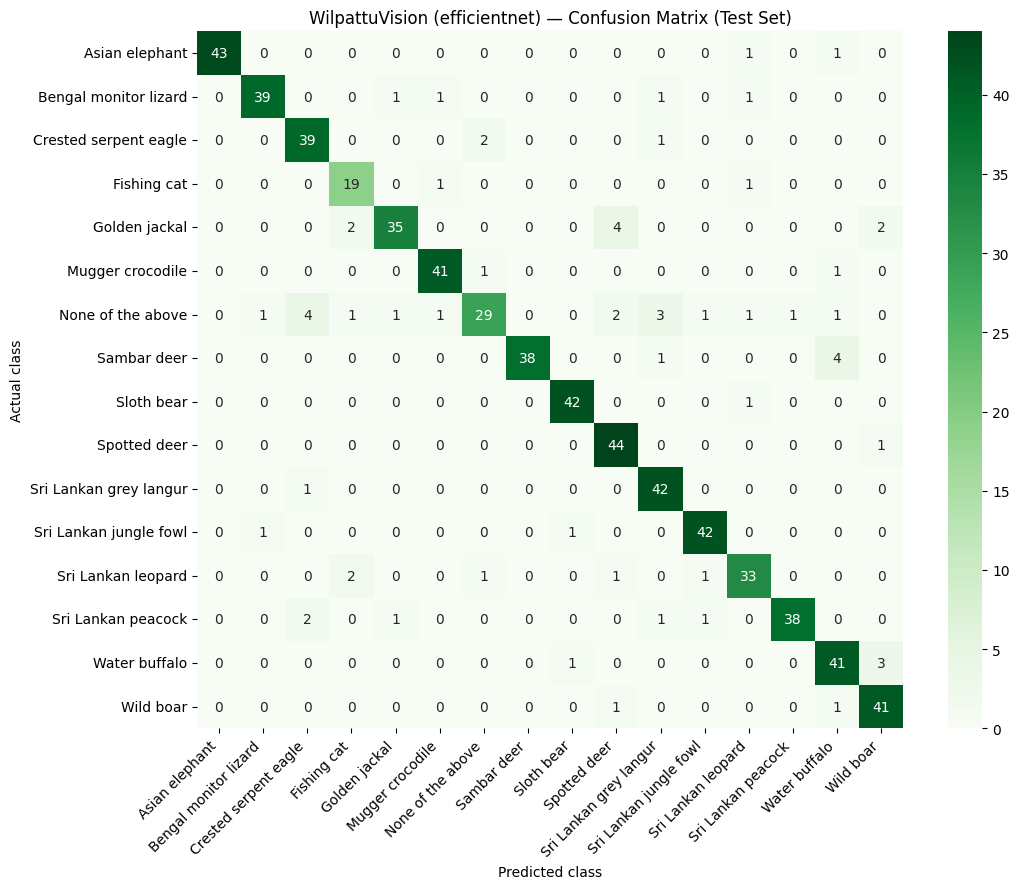

Saved confusion matrix to /content/drive/MyDrive/WilpattuVision/model/confusion_matrix_efficientnet.png

Per-class check against the 80% target:
  Asian elephant                 precision=1.00  recall=0.96
  Bengal monitor lizard          precision=0.95  recall=0.91
  Crested serpent eagle          precision=0.85  recall=0.93
  Fishing cat                    precision=0.79  recall=0.90  <-- BELOW 80% TARGET
  Golden jackal                  precision=0.92  recall=0.81
  Mugger crocodile               precision=0.93  recall=0.95
  None of the above              precision=0.88  recall=0.63  <-- BELOW 80% TARGET
  Sambar deer                    precision=1.00  recall=0.88
  Sloth bear                     precision=0.95  recall=0.98
  Spotted deer                   precision=0.85  recall=0.98
  Sri Lankan grey langur         precision=0.86  recall=0.98
  Sri Lankan jungle fowl         precision=0.93  recall=0.95
  Sri Lankan leopard             precision=0.87  recall=0.87
  Sri Lankan peaco

In [ ]:


import os
import json
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

PROJECT_DIR = '/content/drive/MyDrive/WilpattuVision'
DATA_DIR = os.path.join(PROJECT_DIR, 'data')
MODEL_DIR = os.path.join(PROJECT_DIR, 'model')


MODEL_TO_EVALUATE = "efficientnet"

if MODEL_TO_EVALUATE == "efficientnet":
    IMG_SIZE = (300, 300)
    CHECKPOINT_PATH = os.path.join(MODEL_DIR, 'best_checkpoint_efficientnet.keras')
    FINAL_MODEL_PATH = os.path.join(MODEL_DIR, 'wilpattu_species_model.keras')
    REPORT_PATH = os.path.join(MODEL_DIR, 'classification_report_efficientnet.txt')
    CONFUSION_MATRIX_PATH = os.path.join(MODEL_DIR, 'confusion_matrix_efficientnet.png')
elif MODEL_TO_EVALUATE == "mobilenet":
    IMG_SIZE = (224, 224)
    CHECKPOINT_PATH = os.path.join(MODEL_DIR, 'best_checkpoint_mobilenet.keras')
    FINAL_MODEL_PATH = os.path.join(MODEL_DIR, 'wilpattu_mobilenet_model.keras')
    REPORT_PATH = os.path.join(MODEL_DIR, 'classification_report_mobilenet.txt')
    CONFUSION_MATRIX_PATH = os.path.join(MODEL_DIR, 'confusion_matrix_mobilenet.png')
else:
    raise ValueError("MODEL_TO_EVALUATE must be 'efficientnet' or 'mobilenet'")

BATCH_SIZE = 16
LABEL_MAP_PATH = os.path.join(MODEL_DIR, 'label_map.json')

print(f"Evaluating: {MODEL_TO_EVALUATE}  (input size {IMG_SIZE})\n")



test_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATA_DIR, 'test'),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=False,
)
class_names = test_ds.class_names



with open(LABEL_MAP_PATH) as f:
    saved_label_map = json.load(f)
expected_order = [saved_label_map[str(i)] for i in range(len(saved_label_map))]

if class_names != expected_order:
    raise ValueError(
        "Test set class order does not match label_map.json -- STOPPING "
        "before computing any metrics, since proceeding would silently "
        "compare predictions against the wrong class.\n"
        f"  label_map.json order: {expected_order}\n"
        f"  test set order:       {class_names}\n"
        "Check that data/test/ contains exactly the same class subfolders, "
        "with the same names, as data/train/ did when the training script ran."
    )
print("Test set class order matches label_map.json exactly. Safe to proceed.\n")

display_names = [name.replace("_", " ") for name in class_names]



print(f"{'Species':30s} {'Test images':>12s}")
for folder_name, display_name in zip(class_names, display_names):
    count = len([
        f for f in os.listdir(os.path.join(DATA_DIR, 'test', folder_name))
        if os.path.isfile(os.path.join(DATA_DIR, 'test', folder_name, f))
    ])
    flag = "  <-- small test set, treat its score with caution" if count < 20 else ""
    print(f"{display_name:30s} {count:>12d}{flag}")
print()



model = tf.keras.models.load_model(CHECKPOINT_PATH)



y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)



test_accuracy = (y_true == y_pred).mean()
print(f"Overall test accuracy ({MODEL_TO_EVALUATE}): {test_accuracy:.2%}\n")



report = classification_report(y_true, y_pred, target_names=display_names, digits=3)
print(report)

with open(REPORT_PATH, 'w') as f:
    f.write(f"Model: {MODEL_TO_EVALUATE}\n")
    f.write(f"Overall test accuracy: {test_accuracy:.2%}\n\n")
    f.write(report)
print(f"Saved classification report to {REPORT_PATH}")



cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(11, 9))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Greens',
    xticklabels=display_names, yticklabels=display_names,
)
plt.xlabel('Predicted class')
plt.ylabel('Actual class')
plt.title(f'WilpattuVision ({MODEL_TO_EVALUATE}) \u2014 Confusion Matrix (Test Set)')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(CONFUSION_MATRIX_PATH, dpi=150)
plt.show()
print(f"Saved confusion matrix to {CONFUSION_MATRIX_PATH}")



print("\nPer-class check against the 80% target:")
report_dict = classification_report(y_true, y_pred, target_names=display_names, output_dict=True)
for display_name in display_names:
    metrics = report_dict[display_name]
    flag = ""
    if metrics['precision'] < 0.80 or metrics['recall'] < 0.80:
        flag = "  <-- BELOW 80% TARGET"
    print(f"  {display_name:30s} precision={metrics['precision']:.2f}  "
          f"recall={metrics['recall']:.2f}{flag}")



model.save(FINAL_MODEL_PATH)
print(f"\nFinal model exported to: {FINAL_MODEL_PATH}")
print(f"Label map already verified consistent at the start of this script: "
      f"{LABEL_MAP_PATH}")




Evaluating: mobilenet  (input size (224, 224))

Found 670 files belonging to 16 classes.
Test set class order matches label_map.json exactly. Safe to proceed.

Species                         Test images
Asian elephant                           45
Bengal monitor lizard                    43
Crested serpent eagle                    42
Fishing cat                              21
Golden jackal                            43
Mugger crocodile                         43
None of the above                        47
Sambar deer                              43
Sloth bear                               43
Spotted deer                             45
Sri Lankan grey langur                   43
Sri Lankan jungle fowl                   44
Sri Lankan leopard                       38
Sri Lankan peacock                       43
Water buffalo                            45
Wild boar                                43

Overall test accuracy (mobilenet): 76.72%

                        precision    recall  f1-

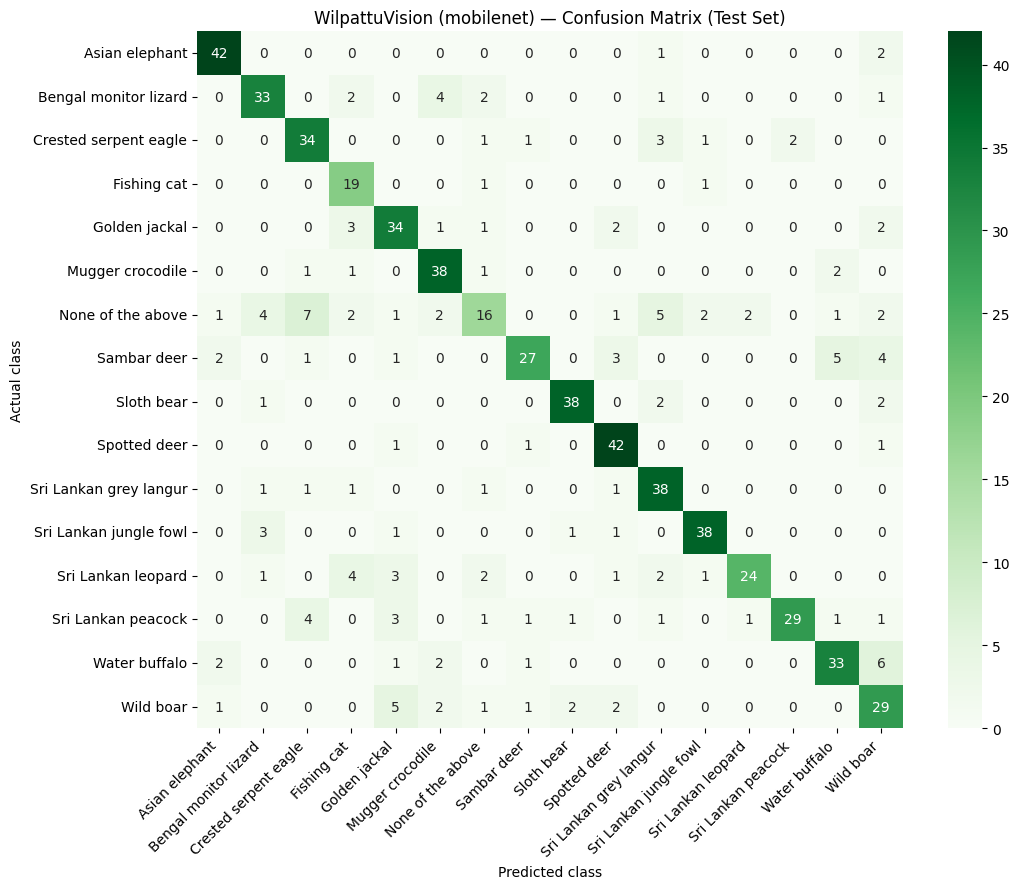

Saved confusion matrix to /content/drive/MyDrive/WilpattuVision/model/confusion_matrix_mobilenet.png

Per-class check against the 80% target:
  Asian elephant                 precision=0.88  recall=0.93
  Bengal monitor lizard          precision=0.77  recall=0.77  <-- BELOW 80% TARGET
  Crested serpent eagle          precision=0.71  recall=0.81  <-- BELOW 80% TARGET
  Fishing cat                    precision=0.59  recall=0.90  <-- BELOW 80% TARGET
  Golden jackal                  precision=0.68  recall=0.79  <-- BELOW 80% TARGET
  Mugger crocodile               precision=0.78  recall=0.88  <-- BELOW 80% TARGET
  None of the above              precision=0.59  recall=0.35  <-- BELOW 80% TARGET
  Sambar deer                    precision=0.84  recall=0.63  <-- BELOW 80% TARGET
  Sloth bear                     precision=0.90  recall=0.88
  Spotted deer                   precision=0.79  recall=0.93  <-- BELOW 80% TARGET
  Sri Lankan grey langur         precision=0.72  recall=0.88  <-- BELOW 

In [ ]:


import os
import json
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

PROJECT_DIR = '/content/drive/MyDrive/WilpattuVision'
DATA_DIR = os.path.join(PROJECT_DIR, 'data')
MODEL_DIR = os.path.join(PROJECT_DIR, 'model')


MODEL_TO_EVALUATE = "mobilenet"

if MODEL_TO_EVALUATE == "efficientnet":
    IMG_SIZE = (300, 300)
    CHECKPOINT_PATH = os.path.join(MODEL_DIR, 'best_checkpoint_efficientnet.keras')
    FINAL_MODEL_PATH = os.path.join(MODEL_DIR, 'wilpattu_species_model.keras')
    REPORT_PATH = os.path.join(MODEL_DIR, 'classification_report_efficientnet.txt')
    CONFUSION_MATRIX_PATH = os.path.join(MODEL_DIR, 'confusion_matrix_efficientnet.png')
elif MODEL_TO_EVALUATE == "mobilenet":
    IMG_SIZE = (224, 224)
    CHECKPOINT_PATH = os.path.join(MODEL_DIR, 'best_checkpoint_mobilenet.keras')
    FINAL_MODEL_PATH = os.path.join(MODEL_DIR, 'wilpattu_mobilenet_model.keras')
    REPORT_PATH = os.path.join(MODEL_DIR, 'classification_report_mobilenet.txt')
    CONFUSION_MATRIX_PATH = os.path.join(MODEL_DIR, 'confusion_matrix_mobilenet.png')
else:
    raise ValueError("MODEL_TO_EVALUATE must be 'efficientnet' or 'mobilenet'")

BATCH_SIZE = 16
LABEL_MAP_PATH = os.path.join(MODEL_DIR, 'label_map.json')

print(f"Evaluating: {MODEL_TO_EVALUATE}  (input size {IMG_SIZE})\n")



test_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATA_DIR, 'test'),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=False,
)
class_names = test_ds.class_names



with open(LABEL_MAP_PATH) as f:
    saved_label_map = json.load(f)
expected_order = [saved_label_map[str(i)] for i in range(len(saved_label_map))]

if class_names != expected_order:
    raise ValueError(
        "Test set class order does not match label_map.json -- STOPPING "
        "before computing any metrics, since proceeding would silently "
        "compare predictions against the wrong class.\n"
        f"  label_map.json order: {expected_order}\n"
        f"  test set order:       {class_names}\n"
        "Check that data/test/ contains exactly the same class subfolders, "
        "with the same names, as data/train/ did when the training script ran."
    )
print("Test set class order matches label_map.json exactly. Safe to proceed.\n")

display_names = [name.replace("_", " ") for name in class_names]



print(f"{'Species':30s} {'Test images':>12s}")
for folder_name, display_name in zip(class_names, display_names):
    count = len([
        f for f in os.listdir(os.path.join(DATA_DIR, 'test', folder_name))
        if os.path.isfile(os.path.join(DATA_DIR, 'test', folder_name, f))
    ])
    flag = "  <-- small test set, treat its score with caution" if count < 20 else ""
    print(f"{display_name:30s} {count:>12d}{flag}")
print()



model = tf.keras.models.load_model(CHECKPOINT_PATH)



y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)



test_accuracy = (y_true == y_pred).mean()
print(f"Overall test accuracy ({MODEL_TO_EVALUATE}): {test_accuracy:.2%}\n")



report = classification_report(y_true, y_pred, target_names=display_names, digits=3)
print(report)

with open(REPORT_PATH, 'w') as f:
    f.write(f"Model: {MODEL_TO_EVALUATE}\n")
    f.write(f"Overall test accuracy: {test_accuracy:.2%}\n\n")
    f.write(report)
print(f"Saved classification report to {REPORT_PATH}")



cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(11, 9))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Greens',
    xticklabels=display_names, yticklabels=display_names,
)
plt.xlabel('Predicted class')
plt.ylabel('Actual class')
plt.title(f'WilpattuVision ({MODEL_TO_EVALUATE}) \u2014 Confusion Matrix (Test Set)')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(CONFUSION_MATRIX_PATH, dpi=150)
plt.show()
print(f"Saved confusion matrix to {CONFUSION_MATRIX_PATH}")



print("\nPer-class check against the 80% target:")
report_dict = classification_report(y_true, y_pred, target_names=display_names, output_dict=True)
for display_name in display_names:
    metrics = report_dict[display_name]
    flag = ""
    if metrics['precision'] < 0.80 or metrics['recall'] < 0.80:
        flag = "  <-- BELOW 80% TARGET"
    print(f"  {display_name:30s} precision={metrics['precision']:.2f}  "
          f"recall={metrics['recall']:.2f}{flag}")



model.save(FINAL_MODEL_PATH)
print(f"\nFinal model exported to: {FINAL_MODEL_PATH}")
print(f"Label map already verified consistent at the start of this script: "
      f"{LABEL_MAP_PATH}")




In [ ]:

import os
import shutil
import tensorflowjs as tfjs
import tensorflow as tf

PROJECT_DIR = '/content/drive/MyDrive/WilpattuVision'
MODEL_DIR = os.path.join(PROJECT_DIR, 'model')

MOBILENET_MODEL_PATH = os.path.join(MODEL_DIR, 'wilpattu_mobilenet_model.keras')
LABEL_MAP_PATH = os.path.join(MODEL_DIR, 'label_map.json')
TFJS_OUTPUT_DIR = os.path.join(MODEL_DIR, 'tfjs_model')

IMG_SIZE = (224, 224)


trained_model = tf.keras.models.load_model(MOBILENET_MODEL_PATH)







new_input = tf.keras.Input(shape=IMG_SIZE + (3,), name="input_image")
x = new_input
skipped_augmentation = False
for layer in trained_model.layers:
    if isinstance(layer, tf.keras.layers.InputLayer):
        continue
    if isinstance(layer, tf.keras.Sequential):
        skipped_augmentation = True
        continue
    x = layer(x)
model = tf.keras.Model(new_input, x, name="wilpattu_mobilenet_inference")

if skipped_augmentation:
    print("Stripped the training-only data augmentation block before "
          "conversion (it's a no-op at inference time and isn't "
          "TF.js-serializable).\n")
else:
    print("No embedded augmentation block found in this model -- "
          "proceeding as-is.\n")




model.save(MOBILENET_MODEL_PATH)
print(f"Re-saved inference-only model to: {MOBILENET_MODEL_PATH}\n")

os.makedirs(TFJS_OUTPUT_DIR, exist_ok=True)
tfjs.converters.save_keras_model(model, TFJS_OUTPUT_DIR)
print(f"TF.js model saved to: {TFJS_OUTPUT_DIR}")
print("Contents:", os.listdir(TFJS_OUTPUT_DIR))




shutil.copy(LABEL_MAP_PATH, os.path.join(TFJS_OUTPUT_DIR, 'label_map.json'))
print("Copied label_map.json into the tfjs_model folder.")

total_size_mb = sum(
    os.path.getsize(os.path.join(TFJS_OUTPUT_DIR, f))
    for f in os.listdir(TFJS_OUTPUT_DIR)
) / 1e6
print(f"\nTotal size of tfjs_model/: {total_size_mb:.1f} MB")


shutil.make_archive('/content/wilpattu_tfjs_model', 'zip', TFJS_OUTPUT_DIR)
from google.colab import files
files.download('/content/wilpattu_tfjs_model.zip')

print("\nIn the PWA, load it with:")
print("  const model = await tf.loadLayersModel('/models/wilpattu/model.json');")
print("and add the whole tfjs_model/ folder's files to your service worker's")
print("precache list so it stays available offline after the first load.")
print("\nAt inference time in JS: resize/normalize the input image to 224x224")
print("(MobileNetV3's include_preprocessing=True handles the actual pixel")
print("normalization inside the model itself, same as it did in Python --")
print("you only need to resize to 224x224 and batch it as [1, 224, 224, 3]).")


Stripped the training-only data augmentation block before conversion (it's a no-op at inference time and isn't TF.js-serializable).



Re-saved inference-only model to: /content/drive/MyDrive/WilpattuVision/model/wilpattu_mobilenet_model.keras

failed to lookup keras version from the file,
    this is likely a weight only file
TF.js model saved to: /content/drive/MyDrive/WilpattuVision/model/tfjs_model
Contents: ['group1-shard1of1.bin', 'model.json']
Copied label_map.json into the tfjs_model folder.

Total size of tfjs_model/: 4.2 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


In the PWA, load it with:
  const model = await tf.loadLayersModel('/models/wilpattu/model.json');
and add the whole tfjs_model/ folder's files to your service worker's
precache list so it stays available offline after the first load.

At inference time in JS: resize/normalize the input image to 224x224
(MobileNetV3's include_preprocessing=True handles the actual pixel
normalization inside the model itself, same as it did in Python --
you only need to resize to 224x224 and batch it as [1, 224, 224, 3]).


## Step 5 — Sanity-check prediction on a new image

Same upload-and-predict flow as before, with a `MODEL_TO_USE` toggle since the two models expect different input sizes.

In [ ]:

import os
import json
import numpy as np
import tensorflow as tf

PROJECT_DIR = '/content/drive/MyDrive/WilpattuVision'
MODEL_DIR = os.path.join(PROJECT_DIR, 'model')

MODEL_TO_USE = "efficientnet"

if MODEL_TO_USE == "efficientnet":
    MODEL_PATH = os.path.join(MODEL_DIR, 'wilpattu_species_model.keras')
    IMG_SIZE = (300, 300)
elif MODEL_TO_USE == "mobilenet":
    MODEL_PATH = os.path.join(MODEL_DIR, 'wilpattu_mobilenet_model.keras')
    IMG_SIZE = (224, 224)
else:
    raise ValueError("MODEL_TO_USE must be 'efficientnet' or 'mobilenet'")

LABEL_MAP_PATH = os.path.join(MODEL_DIR, 'label_map.json')


def load_label_map():
    with open(LABEL_MAP_PATH) as f:
        raw = json.load(f)
    return {int(k): v.replace("_", " ") for k, v in raw.items()}


def predict(image_path, top_k=3):
    model = tf.keras.models.load_model(MODEL_PATH)
    label_map = load_label_map()

    img = tf.keras.utils.load_img(image_path, target_size=IMG_SIZE)
    img_array = tf.keras.utils.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    predictions = model.predict(img_array, verbose=0)[0]
    top_indices = predictions.argsort()[::-1][:top_k]

    print(f"\nPredictions for: {os.path.basename(image_path)}  (model: {MODEL_TO_USE})\n")
    for rank, idx in enumerate(top_indices, start=1):
        species = label_map[idx]
        confidence = predictions[idx] * 100
        print(f"  {rank}. {species:30s} {confidence:.1f}%")

    return [(label_map[idx], float(predictions[idx])) for idx in top_indices]


def predict_from_upload(top_k=3):
    """Option A -- pops up a file picker to upload a photo directly from
    your computer, then runs the same prediction as predict()."""
    from google.colab import files
    uploaded = files.upload()
    if not uploaded:
        print("No file uploaded.")
        return None
    image_path = list(uploaded.keys())[0]
    return predict(image_path, top_k=top_k)


if __name__ == "__main__":

    predict_from_upload()







Saving horse-3.jpg to horse-3.jpg

Predictions for: horse-3.jpg  (model: efficientnet)

  1. Water buffalo                  42.3%
  2. Sambar deer                    23.3%
  3. None of the above              7.9%


In [ ]:

import os
import json
import numpy as np
import tensorflow as tf

PROJECT_DIR = '/content/drive/MyDrive/WilpattuVision'
MODEL_DIR = os.path.join(PROJECT_DIR, 'model')

MODEL_TO_USE = "efficientnet"

if MODEL_TO_USE == "efficientnet":
    MODEL_PATH = os.path.join(MODEL_DIR, 'wilpattu_species_model.keras')
    IMG_SIZE = (300, 300)
else:
    MODEL_PATH = os.path.join(MODEL_DIR, 'wilpattu_mobilenet_model.keras')
    IMG_SIZE = (224, 224)

LABEL_MAP_PATH = os.path.join(MODEL_DIR, 'label_map.json')



ROBUSTNESS_TEST_DIR = os.path.join(PROJECT_DIR, 'robustness_test_images')

CONFIDENCE_THRESHOLD = 0.60
VALID_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.webp'}


def load_label_map():
    with open(LABEL_MAP_PATH) as f:
        raw = json.load(f)
    return {int(k): v.replace("_", " ") for k, v in raw.items()}


def predict_single(model, label_map, image_path, top_k=3):
    img = tf.keras.utils.load_img(image_path, target_size=IMG_SIZE)
    img_array = tf.keras.utils.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    predictions = model.predict(img_array, verbose=0)[0]
    top_indices = predictions.argsort()[::-1][:top_k]

    return [(label_map[idx], float(predictions[idx])) for idx in top_indices]


def main():
    if not os.path.isdir(ROBUSTNESS_TEST_DIR):
        print(f"Folder not found: {ROBUSTNESS_TEST_DIR}")
        print("Create it in Google Drive and add some test images first "
              "(see the guidance in this script's docstring for what "
              "kinds of images to include).")
        return

    image_files = sorted([
        f for f in os.listdir(ROBUSTNESS_TEST_DIR)
        if os.path.splitext(f)[1].lower() in VALID_EXTENSIONS
    ])

    if not image_files:
        print(f"No image files found in {ROBUSTNESS_TEST_DIR}")
        return

    print(f"Loading {MODEL_TO_USE} model and testing {len(image_files)} image(s)...\n")
    model = tf.keras.models.load_model(MODEL_PATH)
    label_map = load_label_map()

    results = []
    for fname in image_files:
        fpath = os.path.join(ROBUSTNESS_TEST_DIR, fname)
        top3 = predict_single(model, label_map, fpath)
        results.append((fname, top3))

    results.sort(key=lambda r: r[1][0][1])

    print(f"{'Image':35s} {'Top prediction':25s} {'Conf.':>7s}  Flag")
    print("-" * 85)
    for fname, top3 in results:
        top_species, top_conf = top3[0]
        flag = "UNCERTAIN" if top_conf < CONFIDENCE_THRESHOLD else ""
        if top_species == "None of the above" and not flag:
            flag = "(caught by None-of-above class)"
        print(f"{fname:35s} {top_species:25s} {top_conf:>6.1%}  {flag}")

    flagged = [(f, t) for f, t in results if t[0][1] < CONFIDENCE_THRESHOLD]
    if flagged:
        print(f"\n{len(flagged)} image(s) below the "
              f"{CONFIDENCE_THRESHOLD:.0%} threshold -- full top-3 breakdown:\n")
        for fname, top3 in flagged:
            print(f"  {fname}:")
            for rank, (species, conf) in enumerate(top3, start=1):
                print(f"    {rank}. {species:25s} {conf:.1%}")
            print()
    else:
        print(f"\nNo images fell below the {CONFIDENCE_THRESHOLD:.0%} threshold.")


if __name__ == "__main__":
    main()


Loading efficientnet model and testing 11 image(s)...



Image                               Top prediction              Conf.  Flag
-------------------------------------------------------------------------------------
car.jpg                             None of the above          19.1%  UNCERTAIN
trees.jpg                           Spotted deer               33.6%  UNCERTAIN
horse.jpg                           Water buffalo              42.3%  UNCERTAIN
grizzly.jpg                         Sloth bear                 55.6%  UNCERTAIN
giraffe.jpg                         Spotted deer               56.8%  UNCERTAIN
rhino.jpg                           Wild boar                  62.2%  
dog.jpg                             None of the above          64.6%  (caught by None-of-above class)
komodo.webp                         Bengal monitor lizard      83.8%  
rscat.jpg                           Fishing cat                97.5%  
whitepeaock.jpg                     Sri Lankan peacock         99.0%  
swcroc.jpg                          Mugger crocodile